THIS IS JUST AN INTRODUCTORY PROGRAM, WHICH WILL HELP TO UNDERSTAND HOW TO MAKE AND IMPLEMENT A NEURAL NETWORK. THE MODEL TRAINED IS NOT THE BEST MODEL HERE, IT IS JUST A BASIC TUTORIAL TO MAKE YOU UNDERSTAND HOW TO TRAIN AND TEST A NEURAL NETWORK

In [36]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

In [2]:
# Read the CSV file using pandas  
df = pd.read_csv("/home/sanskar/DEEP_LEARNING/ANN Projects/Churn_Modelling.csv")

# Check what is inside the data set
df.head(5)

df.shape

(10000, 14)

In [3]:
# To check the information about the dataset 
info = df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [4]:
# Check for duplicated rows 
df.duplicated().sum()

np.int64(0)

In [5]:
# Check for null values 
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [6]:
# Our target is the exited column, so we can check the information 
def count_column(column_name):
    return df[column_name].value_counts()

count_column("Exited")
count_column("Gender")
count_column("Geography")

# The dataset is imbalanced as seen from the output

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [7]:
df.drop(columns=["RowNumber", "CustomerId", "Surname"], inplace=True)

In [8]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
df = pd.get_dummies(df, columns=["Geography", "Gender"], drop_first=True)


In [10]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,True,False,True


In [11]:
# Before model building, we should scale specific columns of the dataset..The reason being is look at the Balance, there are also huge number and this would cause the model not to converge
# so we will first do train_test_split 

from sklearn.model_selection import train_test_split

X = df.drop(columns = ["Exited"])
y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=1)

In [12]:
X_train.shape

(8000, 11)

In [13]:
# Now scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [14]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]], shape=(8000, 11))

In [15]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential 
from tensorflow.keras.layers import Dense

I0000 00:00:1783352720.617059   31842 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1783352720.673356   31842 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783352721.964545   31842 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [16]:
# Keras has two type of models 
# 1. sequential and 2. Non sequential 
# We will be focusing on Sequential 
model = Sequential()
 
'''
Add layers  
1. Input layer 
2. Hidden layer 
3. Output layer
'''

model.add(Dense(11, activation= 'relu', input_dim = 11))
# Increase another layer 
model.add(Dense(11, activation= 'relu'))
model.add(Dense(1, activation= 'sigmoid'))

/home/sanskar/jupyter-env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1783352722.316836   31842 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# How the model will learn..how will it calculte loss funnctions and update weights ?? 
model.compile(loss="binary_crossentropy", optimizer="Adam", metrics=["accuracy"])

In [19]:
# Now the instruction to train are given ...now the training happens 
history = model.fit(X_train_scaled, y_train, epochs=100, validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7664 - loss: 0.5134 - val_accuracy: 0.7981 - val_loss: 0.4554
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8030 - loss: 0.4464 - val_accuracy: 0.8062 - val_loss: 0.4353
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8117 - loss: 0.4292 - val_accuracy: 0.8194 - val_loss: 0.4232
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8259 - loss: 0.4174 - val_accuracy: 0.8231 - val_loss: 0.4116
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8341 - loss: 0.4052 - val_accuracy: 0.8250 - val_loss: 0.4008
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8408 - loss: 0.3932 - val_accuracy: 0.8356 - val_loss: 0.3889
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8456 - loss: 0.3810 - val_accuracy: 0.8425 - val_loss: 0.3770
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8497 - loss: 0.3704 - val_accu

In [20]:
# Now to calculate the weights and bias for each layer 
model.layers[0].get_weights()

[array([[ 6.25507310e-02,  4.38835889e-01,  4.38253842e-02,
          1.87405840e-01, -7.16276839e-02, -1.68984607e-01,
         -4.09774750e-01, -1.54397994e-01,  2.71031052e-01,
          1.30286559e-01, -1.58409432e-01],
        [-7.44347453e-01, -2.24769682e-01, -1.02944386e+00,
          8.81866336e-01, -8.30831826e-01,  2.79638052e-01,
         -2.73255467e-01,  2.84636438e-01, -7.82882452e-01,
         -8.57754722e-02,  5.79171658e-01],
        [-2.44941220e-01, -3.92836243e-01, -1.30561948e-01,
         -1.60252020e-01,  9.37564820e-02, -5.74216321e-02,
          3.65185797e-01,  1.65714845e-02, -3.10159743e-01,
         -6.78744316e-02,  1.56328082e-01],
        [-2.29537249e-01, -3.78168494e-01,  5.81918538e-01,
         -8.05393979e-02,  3.42534035e-01, -4.12830502e-01,
         -4.61480543e-02,  4.90375876e-01, -3.07837278e-01,
          7.34484553e-01, -3.25054042e-02],
        [ 2.59619623e-01,  1.66764528e-01, -4.06787127e-01,
          7.29017913e-01,  4.52835798e-01, -

In [21]:
# for the second layer 
model.layers[1].get_weights()

[array([[-0.5266994 ,  0.6056203 ,  0.24296781,  0.45340085,  0.30508336,
         -0.54622626, -0.23747657,  0.26472074, -0.14351586, -0.0965902 ,
         -0.72293425],
        [ 0.12328181, -0.19764103, -0.10959785,  0.5037552 , -0.43604153,
          0.49374422,  0.10555008, -0.3414544 ,  0.13029616,  0.24889371,
          0.42258906],
        [-0.35020286,  0.5724979 ,  0.63539296, -0.18547752, -0.376927  ,
          0.23871672, -0.11744066,  0.2970118 , -0.12037839, -0.00867632,
         -0.81248504],
        [ 0.05380778,  0.24076134,  0.44256958,  0.21721914,  0.1435934 ,
         -0.4651728 ,  0.6846102 , -0.97225887,  0.27397814,  0.28126058,
          0.35259396],
        [ 0.00992319,  0.4456819 ,  0.4869674 ,  0.45027184,  0.19190234,
         -0.03273309,  0.4971136 , -0.19195162,  0.4586044 , -0.6030721 ,
         -0.44349027],
        [ 0.49488592, -0.39817455, -0.54363936, -0.2147    , -0.171361  ,
         -0.3504227 , -0.4099153 ,  0.12109564, -0.7881938 , -0.0602135

In [22]:
y_log = model.predict(X_test_scaled)
y_log

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


array([[0.0291617 ],
       [0.13323818],
       [0.03810528],
       ...,
       [0.01447881],
       [0.06623754],
       [0.4309514 ]], shape=(2000, 1), dtype=float32)

In [23]:
# Now as there is a sigmoid function, it will return probabilities so in this code we shall convert the probabilities into 0 and 1 
y_pred = np.where(y_log > 0.5, 1, 0)

In [24]:
# Now we will test the accuracy of the model 
from sklearn.metrics import accuracy_score 
accuracy_score(y_test, y_pred)

0.866

Text(0.5, 0, 'epochs')

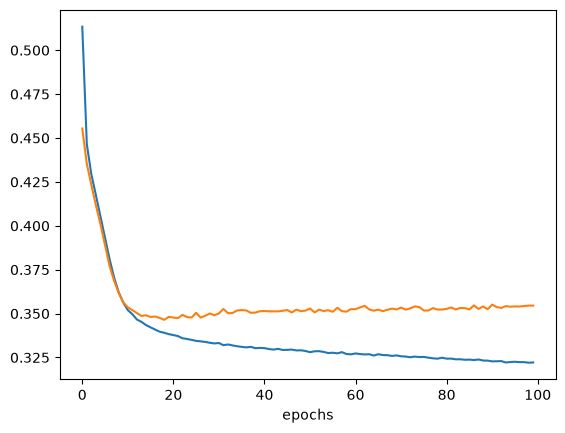

In [28]:
# To see the history of the model we shall retrieve the "history" histogram 
import matplotlib.pyplot as plt 
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.xlabel("epochs")

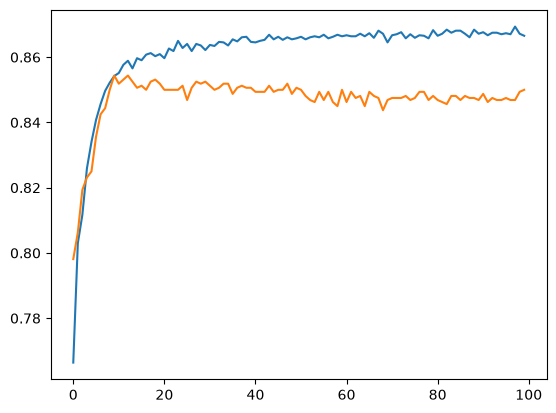

In [35]:
# for accuray 
def plot(attr):
    return plt.plot(history.history[attr])
    

plot(attr = "accuracy")
plot(attr = "val_accuracy")

Now our model has an accuracy of 80%, so we can improve the model by these three things 
- We can increase the number of epochs, lets say it is now 10, we can increase that to 100 or 1000
- We can use any other activation function, ReLU works best in most of the cases
- We can also increase the hidden layers

These are the number of ways we can do to improve our model, howeverall the changes should be experimented to avoid overfitting.